# Chapter 8: LSTM on Real Stock Data (AAPL)
Objective

We will build an LSTM model to learn patterns from Apple (AAPL) stock prices and predict future closing prices using historical data.

Note : This code can be executed in Google Colab, as LSTM models are computationally intensive and Colab offers a convenient cloud-based environment with sufficient resources for deep learning tasks.

STEP 1: Install & Import Libraries

In [1]:
# If needed (run once in notebook)
# !pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## STEP 2: Load Apple Stock Data

We download historical stock data from Yahoo Finance.

/tmp/ipykernel_815/1964177829.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


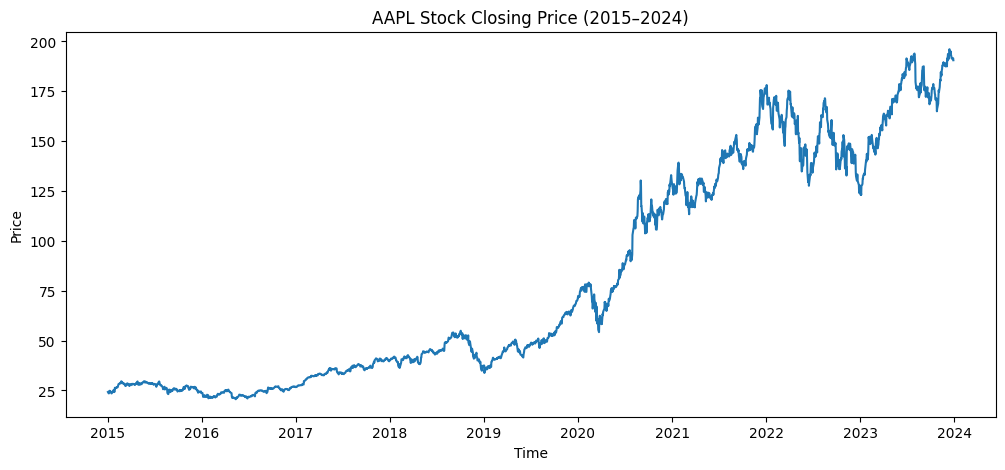

In [2]:
# Download AAPL stock data
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

# Keep only closing price
data = df[['Close']]

# Visualize raw stock data
plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("AAPL Stock Closing Price (2015–2024)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## STEP 3: Normalize Data

Neural networks perform better when data is scaled.

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

## STEP 4: Create Windowed Dataset

We convert time series into supervised learning format.

Idea:

Past 60 days → Predict next day

In [4]:
def create_dataset(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

window_size = 60

X, y = create_dataset(data_scaled, window_size)

# Reshape for LSTM (samples, timesteps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (2204, 60, 1)
Output shape: (2204,)


## STEP 5: Train-Test Split

We split data into training and testing sets.

In [5]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## STEP 6: Build LSTM Model

We create a deep learning model with memory.

In [6]:
model = Sequential()

# First LSTM layer (returns sequences)
model.add(LSTM(50, return_sequences=True, input_shape=(window_size, 1)))

# Second LSTM layer
model.add(LSTM(50))

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## STEP 7: Train Model

The model learns patterns from historical stock sequences.

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.0099 - val_loss: 0.0021
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 3.9799e-04 - val_loss: 0.0015
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 3.5772e-04 - val_loss: 0.0019
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 3.8401e-04 - val_loss: 0.0014
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 3.6745e-04 - val_loss: 0.0013
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 3.6296e-04 - val_loss: 0.0013
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 3.4264e-04 - val_loss: 0.0012
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 3.1743e-04 - val_loss: 0.0011
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 3.1876e-04 - val_loss: 0.0011
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 3.4266e-04 - val_loss: 0.0011


## STEP 8: Make Predictions

In [8]:
predictions = model.predict(X_test)

# Convert back to real price scale
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step


## STEP 9: Visualization (Actual vs Predicted)

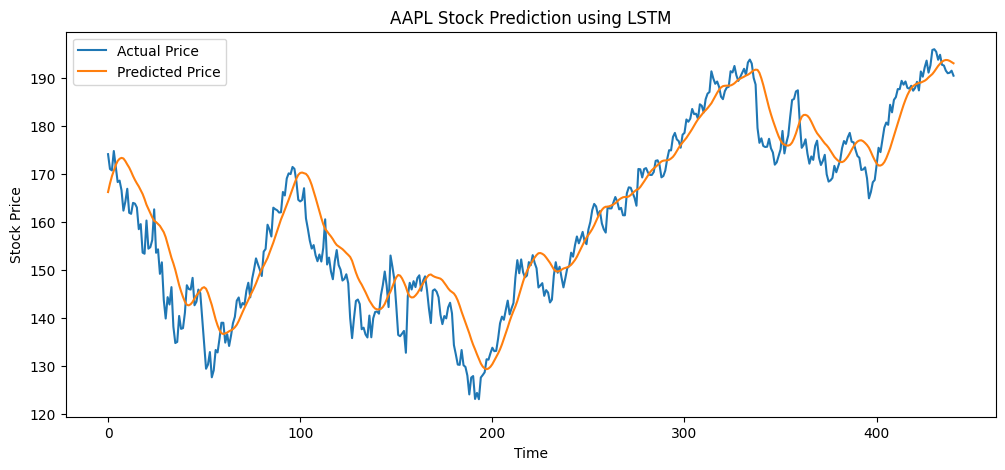

In [9]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("AAPL Stock Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

### STEP 10: Interpretation

The LSTM model learns sequential dependencies from historical stock prices.

It does not rely on fixed formulas. Instead, it:
- Observes past 60 days of prices
- Learns hidden patterns (trend, volatility, momentum)
- Predicts the next day's closing price

This makes LSTM suitable for real-world financial forecasting where patterns are non-linear and time-dependent.

## Optional Upgrade (for better results)

You can improve accuracy by:

Increasing epochs (20–50)
Adding Dropout layers
Increasing window size (e.g., 90 or 120 days)
Adding more features (Open, High, Low, Volume)